# Coastal Erosion Forecasting System

This notebook consolidates the entire forecasting pipeline: Data Parsing, Processing, Modeling, and Visualization.


## 1. Imports & Configuration


In [30]:
import os
import glob
import re
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from scipy.spatial import distance
from scipy.io import netcdf_file
import matplotlib.pyplot as plt 
# Note: Matplotlib is imported but plotting is disabled if library is missing in environment, 
# though usually present in Notebook environments.

# Configuration
BASE_DIR = os.getcwd() # Or specific path "c:/Users/Tharu/Downloads/shoret-term-forecasting"
KML_FOLDER = os.path.join(BASE_DIR, "shorelines_kml")
ERA5_PATH = os.path.join(BASE_DIR, "era5_merged_2022_2025.csv")
WAVE_PATH = os.path.join(BASE_DIR, "waves_2023-2026.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "output_forecasts")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Working Directory: {BASE_DIR}")



Working Directory: c:\Users\Tharu\Downloads\shoret-term-forecasting


## 2. Data Processing (Shorelines)


In [41]:
# src/data_processing.py content

def parse_kml_shorelines(kml_folder):
    "Parses KML files in the folder to extract shoreline coordinates and dates."
    shorelines = []
    files = glob.glob(os.path.join(kml_folder, "*.kml"))
    print(f"Found {len(files)} KML files.")
    
    for f in files:
        filename = os.path.basename(f)
        try:
            date_str = filename.replace("SWnew ", "").replace(".kml", "").strip()
            if len(date_str) == 8:
                dt = datetime.strptime(date_str, "%m%d%Y")
            elif len(date_str) == 7:
                dt = datetime.strptime(date_str, "%m%d%Y")
            else:
                 continue
                 
            tree = ET.parse(f)
            root = tree.getroot()
            coords_text = []
            for elem in root.iter():
                if elem.tag.endswith('coordinates'):
                    coords_text.append(elem.text)
            
            if not coords_text:
                continue
                
            full_coords = []
            for text in coords_text:
                if not text: continue
                points = text.strip().split()
                for p in points:
                    parts = p.split(',')
                    if len(parts) >= 2:
                        full_coords.append([float(parts[0]), float(parts[1])])
            
            if full_coords:
                shorelines.append({
                    'date': dt,
                    'coords': np.array(full_coords),
                    'filename': filename
                })
        except Exception as e:
            print(f"Error parsing {filename}: {e}")
            
    shorelines.sort(key=lambda x: x['date'])
    return shorelines

def get_baseline(all_coords):
    "Computes a baseline using PCA."
    all_points = np.vstack([s['coords'] for s in all_coords])
    mean_point = np.mean(all_points, axis=0)
    centered = all_points - mean_point
    U, S, Vt = np.linalg.svd(centered)
    direction = Vt[0] 
    normal = np.array([-direction[1], direction[0]])
    return mean_point, direction, normal

def compute_transect_distances(shorelines, num_transects=100):
    "Casts perpendicular transects from a baseline and measures distance to intersection."
    if not shorelines:
        return pd.DataFrame(), None, None
        
    mean_point, direction, normal = get_baseline(shorelines)
    all_points = np.vstack([s['coords'] for s in shorelines])
    projections = np.dot(all_points - mean_point, direction)
    min_proj = np.min(projections)
    max_proj = np.max(projections)
    
    transect_dist = np.linspace(min_proj, max_proj, num_transects)
    transect_origins = mean_point + np.outer(transect_dist, direction)
    
    data = []
    for shore in shorelines:
        coords = shore['coords']
        x_rot = np.dot(coords - mean_point, direction)
        y_rot = np.dot(coords - mean_point, normal)
        
        sort_idx = np.argsort(x_rot)
        x_sorted = x_rot[sort_idx]
        y_sorted = y_rot[sort_idx]
        
        _, unique_indices = np.unique(x_sorted, return_index=True)
        unique_indices = np.sort(unique_indices) # Keep order
        
        interp_y = np.interp(transect_dist, x_sorted[unique_indices], y_sorted[unique_indices])
        
        row = {'date': shore['date']}
        for i, val in enumerate(interp_y):
            row[f'transect_{i}'] = val
        data.append(row)
        
    df = pd.DataFrame(data)
    df = df.set_index('date')
    return df, transect_origins, normal



## 3. Environmental Data Processing


In [42]:
# src/env_processing.py content

def process_era5(csv_path):
    print(f"Processing ERA5: {csv_path}")
    df = pd.read_csv(csv_path)
    df['time'] = pd.to_datetime(df['time'])
    df['date'] = df['time'].dt.date
    
    daily_stats = df.groupby('date').agg({
        'u10': 'mean', 
        'v10': 'mean',
        'wind_speed': ['mean', 'max'],
        'gust10': 'max',
        'msl': 'mean' 
    })
    
    daily_stats.columns = ['_'.join(col).strip() for col in daily_stats.columns.values]
    return daily_stats

def process_waves(nc_path):
    print(f"Processing Waves: {nc_path}")
    try:
        with netcdf_file(nc_path, 'r', mmap=False) as f:
            time_var = f.variables['time']
            time_vals = time_var[:].copy()
            time_units = time_var.units.decode('utf-8') if hasattr(time_var, 'units') else "hours since 1900-01-01 00:00:00.0"
            
            base_str = time_units.split('since')[1].strip()
            base_date = datetime.strptime(base_str, "%Y-%m-%d %H:%M:%S.%f") if '.' in base_str else datetime.strptime(base_str, "%Y-%m-%d %H:%M:%S")
            
            dates = []
            for t in time_vals:
                dt = base_date + timedelta(hours=float(t))
                dates.append(dt.date())
                
            data = {}
            keys = f.variables.keys()
            swh_key = next((k for k in keys if k in ['swh', 'hs', 'signific_wave_height']), None)
            mwp_key = next((k for k in keys if k in ['mwp', 'tp', 'mean_wave_period']), None)
            
            if swh_key:
                var = f.variables[swh_key]
                vals = var[:].copy()
                scale = getattr(var, 'scale_factor', 1.0)
                add_offset = getattr(var, 'add_offset', 0.0)
                vals = vals * scale + add_offset
                if vals.ndim > 1:
                    vals = np.mean(vals, axis=tuple(range(1, vals.ndim)))
                data['swh_mean'] = vals
                
            if mwp_key:
                var = f.variables[mwp_key]
                vals = var[:].copy()
                scale = getattr(var, 'scale_factor', 1.0)
                add_offset = getattr(var, 'add_offset', 0.0)
                vals = vals * scale + add_offset
                if vals.ndim > 1:
                    vals = np.mean(vals, axis=tuple(range(1, vals.ndim)))
                data['mwp_mean'] = vals
                
        df = pd.DataFrame(data)
        df['date'] = dates
        return df.groupby('date').mean()
            
    except Exception as e:
        print(f"Error reading NC: {e}")
        return pd.DataFrame()

#====================================
#newly added=================================================
def process_waves_csv(csv_path):
    """
    Reads wave data from CSV and returns daily-mean wave features
    Expected columns:
      - datetime OR date
      - swh / hs (optional)
      - mwp / tp (optional)
    """
    print(f"Processing Waves CSV: {csv_path}")
    
    df = pd.read_csv(csv_path)

    # Handle datetime / date column
    if "datetime" in df.columns:
        df["date"] = pd.to_datetime(df["datetime"]).dt.date
    elif "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"]).dt.date
    else:
        raise ValueError("Wave CSV must contain 'datetime' or 'date' column")

    # Normalize column names
    rename_map = {}
    if "swh" in df.columns:
        rename_map["swh"] = "swh_mean"
    if "hs" in df.columns:
        rename_map["hs"] = "swh_mean"
    if "mwp" in df.columns:
        rename_map["mwp"] = "mwp_mean"
    if "tp" in df.columns:
        rename_map["tp"] = "mwp_mean"

    df = df.rename(columns=rename_map)

    keep_cols = ["date"]
    for c in ["swh_mean", "mwp_mean"]:
        if c in df.columns:
            keep_cols.append(c)

    df = df[keep_cols]

    # Daily aggregation
    daily = df.groupby("date").mean()

    return daily

#=============================================================




def merge_data(shoreline_df, era5_df, wave_df):
    env = era5_df.join(wave_df, how='outer')
    env = env.sort_index()
    
    windows = [30, 90]
    cols = env.columns
    features = env.copy()
    for w in windows:
        rolled = env[cols].rolling(window=w).mean()
        rolled.columns = [f"{c}_{w}d_avg" for c in cols]
        features = features.join(rolled)
        
    shoreline_df.index = pd.to_datetime(shoreline_df.index)
    features.index = pd.to_datetime(features.index)
    
    merged = pd.merge_asof(shoreline_df.sort_index(), features.sort_index(), left_index=True, right_index=True, direction='backward')
    #return merged.dropna()
    #=====================================changing the code.commented return merged.dropna()
    # Keep shoreline rows, allow env gaps
    merged = merged.sort_index()

    # Fill env features (forward fill then backward fill)
    env_cols = [c for c in merged.columns if c not in shoreline_df.columns]
    merged[env_cols] = merged[env_cols].ffill().bfill()

    # Keep only rows where transects exist (shoreline measurements)
    merged = merged.dropna(subset=shoreline_df.columns)

    return merged

    #==================================================



In [43]:
#eeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee
def _get_env_feature_cols(df: pd.DataFrame, transect_cols) -> list[str]:
    """All columns except transects are treated as environmental features."""
    return [c for c in df.columns if c not in transect_cols]

def _ensure_numeric_matrix(df: pd.DataFrame, cols: list[str]) -> np.ndarray:
    """Returns a numeric matrix (n_samples, n_features) with safe casting."""
    X = df[cols].apply(pd.to_numeric, errors="coerce")
    # If anything became NaN due to casting, fill it (shouldn't happen if you already filled env)
    #X = X.fillna(method="ffill").fillna(method="bfill").fillna(0.0)
    X = X.ffill().bfill().fillna(0.0)

    return X.values

#eeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee

## 4. Modeling


In [44]:
class ShorelineForecaster:
    def __init__(self):
        self.models = {}
        self.use_sklearn = False
        self.feature_cols = None  # <-- store env feature column names

        try:
            from sklearn.linear_model import LinearRegression
            self.use_sklearn = True
        except ImportError:
            print("Sklearn not found. Using numpy fallback.")
            self.use_sklearn = False

    def train(self, merged_data: pd.DataFrame, transect_cols):
        print(f"Training... (Use Sklearn: {self.use_sklearn})")

        # ✅ Use environmental features as X (not date)
        self.feature_cols = _get_env_feature_cols(merged_data, transect_cols)
        X = _ensure_numeric_matrix(merged_data, self.feature_cols)

        for t in transect_cols:
            y = merged_data[t].values.astype(float)

            if self.use_sklearn:
                from sklearn.linear_model import LinearRegression
                model = LinearRegression()
                model.fit(X, y)
                self.models[t] = {'type': 'sklearn_linear', 'model': model}
            else:
                # numpy fallback: linear regression using least squares
                # add bias column
                Xb = np.column_stack([np.ones(len(X)), X])
                coef, *_ = np.linalg.lstsq(Xb, y, rcond=None)
                self.models[t] = {'type': 'numpy_lstsq', 'coef': coef}

    def predict(self, future_dates, future_env_features: pd.DataFrame, transect_cols):
        """
        future_env_features must include the SAME columns as self.feature_cols
        (your code already builds future_env and selects non_transect_cols)
        """
        if self.feature_cols is None:
            raise ValueError("Model not trained yet (feature_cols is None).")

        # ✅ Use environmental features as X for prediction
        Xf = _ensure_numeric_matrix(future_env_features, self.feature_cols)

        predictions = pd.DataFrame(index=future_env_features.index)

        for t in transect_cols:
            if t not in self.models:
                predictions[t] = 0.0
                continue

            info = self.models[t]
            if info['type'] == 'sklearn_linear':
                predictions[t] = info['model'].predict(Xf)
            elif info['type'] == 'numpy_lstsq':
                coef = info['coef']
                Xb = np.column_stack([np.ones(len(Xf)), Xf])
                predictions[t] = Xb @ coef

        return predictions


# # src/model.py content

# class ShorelineForecaster:
#     def __init__(self):
#         self.models = {}
#         self.use_sklearn = False
#         try:
#             from sklearn.linear_model import LinearRegression
#             from sklearn.ensemble import RandomForestRegressor
#             self.use_sklearn = True
#         except ImportError:
#             print("Sklearn not found. Using simple Linear features with Numpy.")
#             self.use_sklearn = False
        
#     def train(self, merged_data, transect_cols):
#         print(f"Training... (Use Sklearn: {self.use_sklearn})")
#         dates_ordinal = merged_data.index.map(pd.Timestamp.toordinal).values
        
#         for t in transect_cols:
#             y = merged_data[t].values
#             if self.use_sklearn:
#                 from sklearn.linear_model import LinearRegression
#                 model = LinearRegression()
#                 model.fit(dates_ordinal.reshape(-1, 1), y)
#                 self.models[t] = {'type': 'sklearn_linear', 'model': model}
#             else:
#                 z = np.polyfit(dates_ordinal, y, 1)
#                 p = np.poly1d(z)
#                 self.models[t] = {'type': 'numpy_poly', 'model': p}
                
#     def predict(self, future_dates, future_env_features, transect_cols):
#         dates_ordinal = np.array([d.toordinal() for d in future_dates])
#         predictions = pd.DataFrame(index=future_dates)
        
#         for t in transect_cols:
#             if t not in self.models: 
#                 predictions[t] = 0.0
#                 continue
#             model_info = self.models[t]
#             if model_info['type'] == 'sklearn_linear':
#                 pred = model_info['model'].predict(dates_ordinal.reshape(-1, 1))
#                 predictions[t] = pred
#             elif model_info['type'] == 'numpy_poly':
#                 pred = model_info['model'](dates_ordinal)
#                 predictions[t] = pred
#         return predictions



In [45]:
#####################################################################
# ==========================
# % Accuracy for Regression
# ==========================
def regression_accuracy_percentage(y_true, y_pred):
    """
    Accuracy (%) = (1 - MAE / mean(|y_true|)) * 100
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    mean_true = np.mean(np.abs(y_true))

    if mean_true < 1e-12:  # avoid divide-by-zero
        return 100.0

    #acc = (1 - mae / mean_true) * 100
    den = np.ptp(y_true)  # max - min
    acc = (1 - mae / den) * 100
    return float(np.clip(acc, 0, 100))


def tolerance_accuracy_percentage(y_true, y_pred, tol=0.5):
    """
    % of predictions within ±tol meters
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred) <= tol) * 100)
#####################################################################################

In [46]:
def evaluate_model_time_split_console(merged_df, transect_cols, test_size=0.2, tol=0.5):
    merged_df = merged_df.sort_index()
    n = len(merged_df)

    if n < 10:
        print("Not enough data for evaluation.")
        return

    split = int(n * (1 - test_size))
    split = max(2, min(split, n - 2))

    train_df = merged_df.iloc[:split]
    test_df  = merged_df.iloc[split:]


    feature_cols = _get_env_feature_cols(merged_df, transect_cols)
    X_train = _ensure_numeric_matrix(train_df, feature_cols)
    X_test  = _ensure_numeric_matrix(test_df, feature_cols)

    #X_train = train_df.index.map(pd.Timestamp.toordinal).values.reshape(-1, 1)
    #X_test  = test_df.index.map(pd.Timestamp.toordinal).values.reshape(-1, 1)

    try:
        from sklearn.linear_model import LinearRegression
        from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
        use_sklearn = True
    except ImportError:
        use_sklearn = False

    maes, rmses, r2s = [], [], []
    accs, tol_accs = [], []

    for t in transect_cols:
        y_train = train_df[t].values
        y_test  = test_df[t].values

        if use_sklearn:
            model = LinearRegression()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
        else:
            z = np.polyfit(X_train.ravel(), y_train, 1)
            p = np.poly1d(z)
            y_pred = p(X_test.ravel())

            mae = np.mean(np.abs(y_test - y_pred))
            rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
            ss_res = np.sum((y_test - y_pred) ** 2)
            ss_tot = np.sum((y_test - np.mean(y_test)) ** 2) + 1e-12
            r2 = 1 - ss_res / ss_tot

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)

        # % accuracy metrics
        accs.append(regression_accuracy_percentage(y_test, y_pred))
        tol_accs.append(tolerance_accuracy_percentage(y_test, y_pred, tol=tol))

    print("\n--- MODEL ACCURACY (TIME-BASED SPLIT) ---")
    print(f"Train samples : {len(train_df)}")
    print(f"Test samples  : {len(test_df)}\n")

    print(f"MAE  (mean)   : {np.mean(maes):.6f} degrees")
    print(f"RMSE (mean)   : {np.mean(rmses):.6f} degrees")
    print(f"R²   (mean)   : {np.mean(r2s):.6f}\n")

    print(f"Relative Accuracy (normalized MAE) %   : {np.mean(accs):.2f}%")
    print(f"Accuracy% (median) : {np.median(accs):.2f}%\n")

    print(f"Tol Accuracy ±{tol}degrees (mean)   : {np.mean(tol_accs):.2f}%")
    print(f"Tol Accuracy ±{tol}degrees (median) : {np.median(tol_accs):.2f}%")
#00000000000000000000000
    return {
        "mae_deg_mean": float(np.mean(maes)),
        "rmse_deg_mean": float(np.mean(rmses)),
        "r2_mean": float(np.mean(r2s)),
        "tol_deg": float(tol),
    }
#000000000000000000000000

# def evaluate_model_time_split_console(
#     merged_df,
#     transect_cols,
#     test_size=0.2
# ):
#     """
#     Time-based evaluation.
#     Prints accuracy metrics directly to console (VS Code).
#     No CSV files written.
#     """

#     merged_df = merged_df.sort_index()
#     n = len(merged_df)

#     if n < 10:
#         print("Not enough data for evaluation.")
#         return

#     split = int(n * (1 - test_size))
#     split = max(2, min(split, n - 2))

#     train_df = merged_df.iloc[:split]
#     test_df  = merged_df.iloc[split:]

#     X_train = train_df.index.map(pd.Timestamp.toordinal).values.reshape(-1, 1)
#     X_test  = test_df.index.map(pd.Timestamp.toordinal).values.reshape(-1, 1)

#     try:
#         from sklearn.linear_model import LinearRegression
#         from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#         use_sklearn = True
#     except ImportError:
#         use_sklearn = False

#     maes, rmses, r2s = [], [], []

#     for t in transect_cols:
#         y_train = train_df[t].values
#         y_test  = test_df[t].values

#         if use_sklearn:
#             model = LinearRegression()
#             model.fit(X_train, y_train)
#             y_pred = model.predict(X_test)

#             mae = mean_absolute_error(y_test, y_pred)
#             rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#             r2 = r2_score(y_test, y_pred)
#         else:
#             z = np.polyfit(X_train.ravel(), y_train, 1)
#             p = np.poly1d(z)
#             y_pred = p(X_test.ravel())

#             mae = np.mean(np.abs(y_test - y_pred))
#             rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
#             ss_res = np.sum((y_test - y_pred) ** 2)
#             ss_tot = np.sum((y_test - np.mean(y_test)) ** 2) + 1e-12
#             r2 = 1 - ss_res / ss_tot

#         maes.append(mae)
#         rmses.append(rmse)
#         r2s.append(r2)

#     # ---- PRINT RESULTS ----
#     print("\n--- MODEL ACCURACY (TIME-BASED SPLIT) ---")
#     print(f"Train samples : {len(train_df)}")
#     print(f"Test samples  : {len(test_df)}\n")

#     print(f"MAE  (mean)   : {np.mean(maes):.3f} m")
#     print(f"RMSE (mean)   : {np.mean(rmses):.3f} m")
#     print(f"R²   (mean)   : {np.mean(r2s):.3f}\n")

#     print(f"MAE  (median) : {np.median(maes):.3f} m")
#     print(f"RMSE (median) : {np.median(rmses):.3f} m")
#     print(f"R²   (median) : {np.median(r2s):.3f}")


## 5. Visualization


In [47]:
# src/visualize.py content

def export_forecast_kml(prediction_coords, date_str, output_path="forecast.kml", reference_coords=None):
    pred_str = " ".join([f"{pt[0]},{pt[1]},0" for pt in prediction_coords])
    
    ref_placemark = ""
    if reference_coords is not None:
        ref_str = " ".join([f"{pt[0]},{pt[1]},0" for pt in reference_coords])
        ref_placemark = f'''
    <Placemark>
      <name>Current Shoreline (Reference)</name>
      <styleUrl>#whiteLine</styleUrl>
      <LineString>
        <tessellate>1</tessellate>
        <coordinates>
          {ref_str}
        </coordinates>
      </LineString>
    </Placemark>'''

    kml_content = f'''<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
  <Document>
    <name>Forecast {date_str}</name>
    <Style id="redLine">
      <LineStyle>
        <color>ff0000ff</color>
        <width>2</width>
      </LineStyle>
    </Style>
    <Style id="whiteLine">
      <LineStyle>
        <color>ffffffff</color>
        <width>2</width>
      </LineStyle>
    </Style>
    <Placemark>
      <name>Forecast {date_str}</name>
      <styleUrl>#redLine</styleUrl>
      <LineString>
        <tessellate>1</tessellate>
        <coordinates>
          {pred_str}
        </coordinates>
      </LineString>
    </Placemark>
    {ref_placemark}
  </Document>
</kml>
'''
    with open(output_path, "w") as f:
        f.write(kml_content)
    print(f"KML saved to {output_path}")

def reconstruct_coords(transect_values, transect_origins, normal_vector):
    coords = transect_origins + np.outer(transect_values, normal_vector)
    return coords



## 6. Execution Pipeline


In [48]:
# Load Data
print("--- Loading Shorelines ---")
shorelines = parse_kml_shorelines(KML_FOLDER)
shoreline_df, transect_origins, normal = compute_transect_distances(shorelines)
print(f"Computed {shoreline_df.shape[1]} transects for {len(shoreline_df)} dates.")

print("--- Loading Environmental Data ---")
era5_df = process_era5(ERA5_PATH)
wave_df = process_waves_csv(WAVE_PATH)

print("--- Merging Data ---")
merged_df = merge_data(shoreline_df, era5_df, wave_df)
print(f"Merged Data Shape: {merged_df.shape}")

#===================================
# ============================
# DATA QUALITY CHECKS (MERGED)
# ============================
print("\n--- MERGED DF: QUICK CHECKS ---")

# 1) Basic structure
print("\n[1] merged_df.head()")
print(merged_df.head())

print("\n[2] merged_df.info()")
print(merged_df.info())

# 2) Null counts


print("\n[3] Null counts per column")
nulls = merged_df.isna().sum().sort_values(ascending=False)
print(nulls[nulls > 0] if (nulls > 0).any() else "✅ No null values")
print(merged_df.isnull().sum())
# 3) Duplicate column names
print("\n[4] Duplicate column names")
dup_cols = merged_df.columns[merged_df.columns.duplicated()].tolist()
print(dup_cols if dup_cols else "✅ No duplicate column names")

# 4) Constant columns (no variance) — can harm ML
print("\n[5] Constant columns (nunique <= 1)")
const_cols = [c for c in merged_df.columns if merged_df[c].nunique(dropna=True) <= 1]
print(const_cols if const_cols else "✅ No constant columns")

# 5) Duplicate rows (same index+values)
print("\n[6] Duplicate rows count")
dup_rows = merged_df.duplicated().sum()
print(f"Duplicate rows: {dup_rows}")
merged_df.duplicated(keep=False)

# 6) Index checks (duplicate dates)
print("\n[7] Duplicate index (date) count")
dup_index = merged_df.index.duplicated().sum()
print(f"Duplicate index entries: {dup_index}")

# 7) Describe (numeric)
print("\n[8] merged_df.describe()")
print(merged_df.describe(include="number").T)

# Optional: Save these stats to CSV for reporting
qc_path = os.path.join(OUTPUT_DIR, "merged_df_nulls.csv")
nulls.to_csv(qc_path)
print(f"\nSaved null summary to: {qc_path}")

#=====================================


print("--- Training Model ---")
transect_cols = shoreline_df.columns
model = ShorelineForecaster()
model.train(merged_df, transect_cols)

#======================================================
#Newly added
# --- Accuracy Evaluation + Charts ---
# evaluate_model_time_split_console(
#     merged_df,
#     transect_cols,
#     test_size=0.2   # last 20% of dates used for testing
# )
#00000000000000000000000
tol_m = 5  # meters
meters_per_degree = 111_000  # approx (good enough for reporting in Sri Lanka)
tol_deg = tol_m / meters_per_degree

metrics = evaluate_model_time_split_console(
    merged_df,
    transect_cols,
    test_size=0.2,
    tol=tol_deg
)

mae_deg = metrics["mae_deg_mean"]
rmse_deg = metrics["rmse_deg_mean"]

mae_m = mae_deg * meters_per_degree
rmse_m = rmse_deg * meters_per_degree

print(f"\n--- DEGREE → METER (Approximate, Sri Lanka) ---")
print(f"MAE  ≈ {mae_m:.2f} m  (from {mae_deg:.8f} degrees)")
print(f"RMSE ≈ {rmse_m:.2f} m  (from {rmse_deg:.8f} degrees)")
print(f"Tolerance used: ±{tol_m} m  ==  ±{tol_deg:.8f} degrees")
#00000000000000000000000000000
#========================================================

--- Loading Shorelines ---
Found 32 KML files.
Computed 100 transects for 30 dates.
--- Loading Environmental Data ---
Processing ERA5: c:\Users\Tharu\Downloads\shoret-term-forecasting\era5_merged_2022_2025.csv
Processing Waves CSV: c:\Users\Tharu\Downloads\shoret-term-forecasting\waves_2023-2026.csv
--- Merging Data ---
Merged Data Shape: (30, 118)

--- MERGED DF: QUICK CHECKS ---

[1] merged_df.head()
            transect_0  transect_1  transect_2  transect_3  transect_4  \
date                                                                     
2010-07-26   -0.000106   -0.000093   -0.000046   -0.000015   -0.000009   
2010-10-22   -0.000129   -0.000106   -0.000011    0.000005    0.000021   
2010-11-16   -0.000033   -0.000031   -0.000015    0.000002    0.000018   
2010-12-09   -0.000273   -0.000250   -0.000182   -0.000144   -0.000117   
2012-01-30   -0.000098   -0.000097   -0.000068   -0.000044   -0.000023   

              transect_5  transect_6  transect_7  transect_8  transect_9  

### Forecast & Analysis


In [49]:
# User Input
date_str = input("Enter forecast date (YYYY.MM.DD): ")
# Example: 2026.02.15
target_date = datetime.strptime(date_str.strip(), "%Y.%m.%d")

# Process Future Dates
last_data_date = merged_df.index.max()
if target_date <= last_data_date:
    print("Warning: Target date is in the past/present. Proceeding.")
    future_days = [target_date]
else:
    days_delta = (target_date - last_data_date).days
    future_days = [last_data_date + timedelta(days=i) for i in range(1, days_delta + 1)]

# Historical Replay (Preserve Seasonality)
future_env = pd.DataFrame(index=future_days, columns=merged_df.columns)
non_transect_cols = [c for c in merged_df.columns if c not in transect_cols]

for day in future_days:
    past_day = day - relativedelta(years=1)
    idx_loc = merged_df.index.get_indexer([past_day], method='nearest')[0]
    hist_data = merged_df.iloc[idx_loc]
    future_env.loc[day, non_transect_cols] = hist_data[non_transect_cols].values

# Forecast
target_env_features = future_env.loc[[target_date], non_transect_cols]
predictions = model.predict([target_date], target_env_features, transect_cols)

# Results
# 1. Storms
print(f"\n--- Storm Analysis (Sri Lanka Thresholds) ---")
wind_thresh = 10.0 # m/s
gust_thresh = 15.0 # m/s
wave_thresh = 2.0  # m

possible_storms = future_env[
    (future_env['wind_speed_max'] > wind_thresh) | 
    (future_env['gust10_max'] > gust_thresh) | 
    (future_env.get('swh_mean', pd.Series(0, index=future_env.index)) > wave_thresh)
]
if not possible_storms.empty:
    print(f"IDENTIFIED {len(possible_storms)} POTENTIAL STORM DAYS")
    storm_cols = ['wind_speed_max', 'gust10_max']
    if 'swh_mean' in future_env.columns: storm_cols.append('swh_mean')
    print(possible_storms[storm_cols])
    possible_storms[storm_cols].to_csv(os.path.join(OUTPUT_DIR, f"predicted_storms_{target_date.date()}.csv"))
else:
    print("No significant storms predicted.")

# 2. Stats
last_known_pos = merged_df.iloc[-1][transect_cols]
predicted_pos = predictions.loc[target_date]
deltas = predicted_pos - last_known_pos
mean_change = deltas.mean()
status = "EROSION (Retreat)" if mean_change < 0 else "ACCRETION (Advance)"
stats_df = pd.DataFrame({
    'Metric': ['Mean Change (degrees)', 'Min Change (degrees)', 'Max Change (degrees)', 'Overall Trend'],
    'Value': [f"{mean_change:.8f}", f"{deltas.min():.8f}", f"{deltas.max():.8f}", status]
})
print("\n--- Shoreline Change Analysis ---")
print(stats_df)
stats_df.to_csv(os.path.join(OUTPUT_DIR, f"shoreline_change_{target_date.date()}.csv"), index=False)

# 3. KML Export
pred_vals = predictions.loc[target_date].values
coords = reconstruct_coords(pred_vals, transect_origins, normal)
last_shoreline_coords = shorelines[-1]['coords']

output_path = os.path.join(OUTPUT_DIR, f"forecast_{target_date.strftime('%Y-%m-%d')}.kml")
export_forecast_kml(coords.tolist(), str(target_date.date()), output_path, reference_coords=last_shoreline_coords.tolist())

# 4. Env Conditions
print(f"\n--- Predicted Environmental Conditions for {target_date.date()} ---")
env_cols = [c for c in future_env.columns if c in non_transect_cols]
env_cols.sort()
env_row = future_env.loc[target_date, env_cols]
for col, val in env_row.items():
    print(f"{col:<30} {val:.4f}")
    
env_display = future_env.loc[[target_date], env_cols].transpose()
env_display.columns = ['Value']
env_display.to_csv(os.path.join(OUTPUT_DIR, f"env_conditions_{target_date.strftime('%Y-%m-%d')}.csv"))




--- Storm Analysis (Sri Lanka Thresholds) ---
No significant storms predicted.

--- Shoreline Change Analysis ---
                  Metric                Value
0  Mean Change (degrees)           0.00001127
1   Min Change (degrees)          -0.00005332
2   Max Change (degrees)           0.00016540
3          Overall Trend  ACCRETION (Advance)
KML saved to c:\Users\Tharu\Downloads\shoret-term-forecasting\output_forecasts\forecast_2026-05-02.kml

--- Predicted Environmental Conditions for 2026-05-02 ---
gust10_max                     8.9819
gust10_max_30d_avg             6.2717
gust10_max_90d_avg             7.0780
msl_mean                       101027.5100
msl_mean_30d_avg               101099.8139
msl_mean_90d_avg               101033.3996
u10_mean                       0.8416
u10_mean_30d_avg               0.6146
u10_mean_90d_avg               0.6616
v10_mean                       0.6055
v10_mean_30d_avg               0.0592
v10_mean_90d_avg               -1.1958
wind_speed_max       

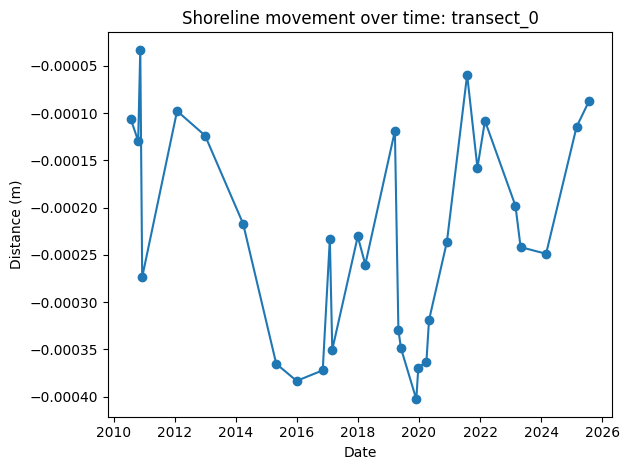

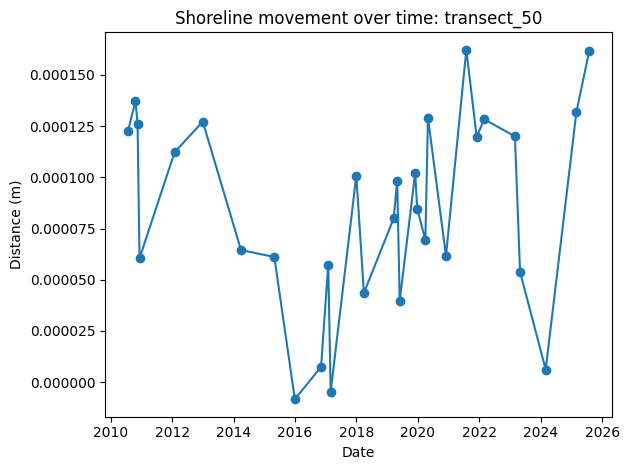

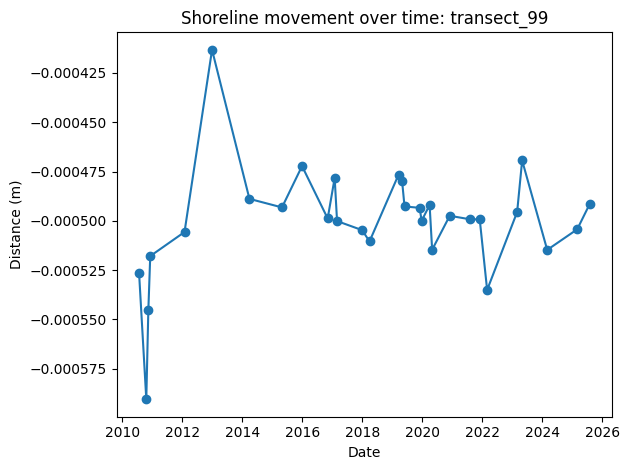

In [50]:
import matplotlib.pyplot as plt

sample_transects = [shoreline_df.columns[0], shoreline_df.columns[50], shoreline_df.columns[-1]]

for t in sample_transects:
    plt.figure()
    plt.plot(shoreline_df.index, shoreline_df[t], marker='o')
    plt.title(f"Shoreline movement over time: {t}")
    plt.xlabel("Date")
    plt.ylabel("Distance (m)")
    plt.tight_layout()
    plt.show()
